In [1]:
# Slide 11
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

11.1 – Chain Code Generation (4-directional)

[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.468] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

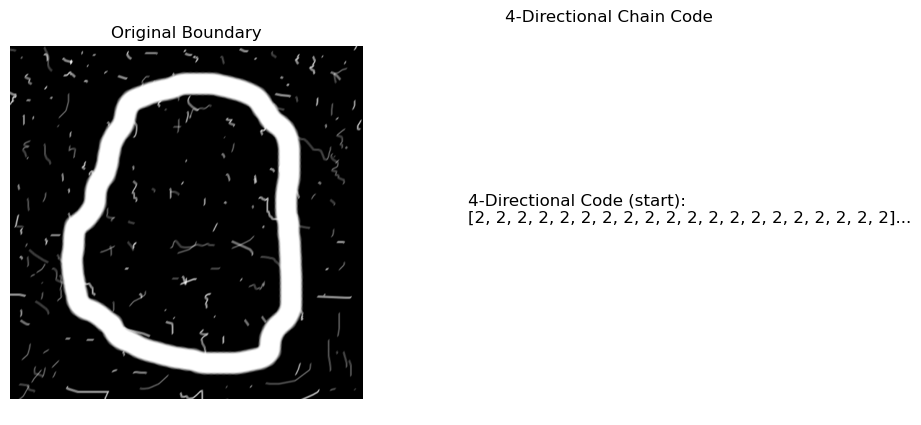

In [2]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1105(a)(noisy_stroke).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Find contours for boundary
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
boundary = contours[0].reshape(-1, 2)

# 4-directional mapping: 0: East, 1: North, 2: West, 3: South
chain_code_4 = []
for i in range(len(boundary) - 1):
    dx = boundary[i+1][0] - boundary[i][0]
    dy = boundary[i+1][1] - boundary[i][1]

    if dx > 0: chain_code_4.append(0)
    elif dy < 0: chain_code_4.append(1)
    elif dx < 0: chain_code_4.append(2)
    elif dy > 0: chain_code_4.append(3)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Boundary'); plt.axis('off')
plt.subplot(1, 2, 2); plt.text(0.1, 0.5, f"4-Directional Code (start):\n{chain_code_4[:20]}...", fontsize=12)
plt.title('4-Directional Chain Code'); plt.axis('off')
plt.show()

11.2 – Chain Code Generation (8-directional)

[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.760] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

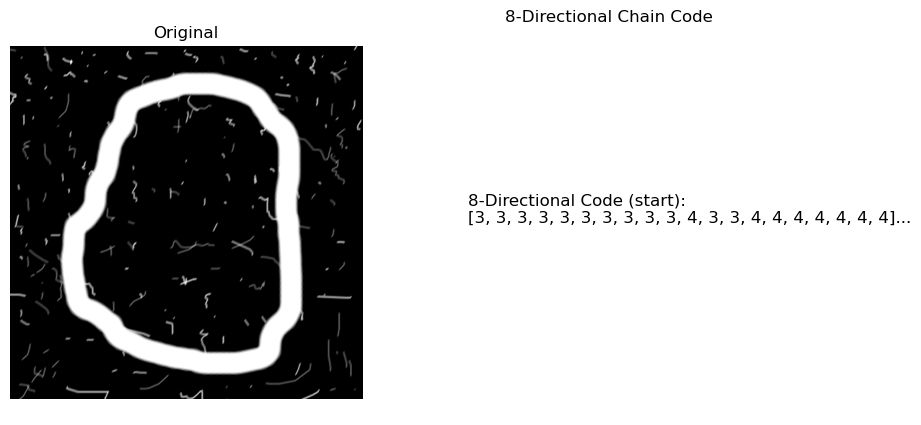

In [3]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1105(a)(noisy_stroke).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
boundary = contours[0].reshape(-1, 2)

# 8-directional mapping (Clockwise starting from East)
# 0:E, 1:SE, 2:S, 3:SW, 4:W, 5:NW, 6:N, 7:NE
def get_8_dir(p1, p2):
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    lookup = {(1,0):0, (1,1):1, (0,1):2, (-1,1):3, (-1,0):4, (-1,-1):5, (0,-1):6, (1,-1):7}
    return lookup.get((dx, dy), 0)

chain_code_8 = [get_8_dir(boundary[i], boundary[i+1]) for i in range(len(boundary)-1)]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.text(0.1, 0.5, f"8-Directional Code (start):\n{chain_code_8[:20]}...", fontsize=12)
plt.title('8-Directional Chain Code'); plt.axis('off')
plt.show()

11.3 – Shape Number Computation (from chain codes)

[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.982] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

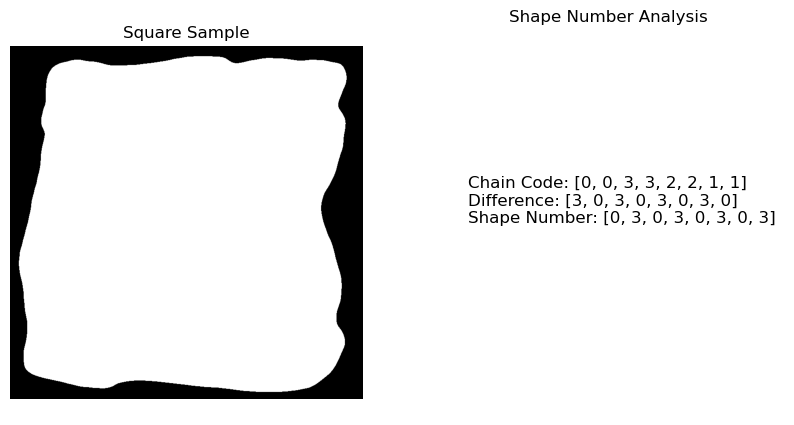

In [4]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1111(b)(square).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Example chain code for a rectangle (4-dir): 00332211
chain = [0, 0, 3, 3, 2, 2, 1, 1]

# 1. First Difference (d_i = (c_i - c_{i-1}) mod 4)
diff = []
for i in range(len(chain)):
    diff.append((chain[i] - chain[i-1]) % 4)

# 2. Shape Number (First difference treated as a circular sequence, normalized to smallest magnitude)
def normalize_to_shape_number(sequence):
    rotations = [sequence[i:] + sequence[:i] for i in range(len(sequence))]
    return min(rotations)

shape_number = normalize_to_shape_number(diff)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Square Sample'); plt.axis('off')
plt.subplot(1, 2, 2); plt.text(0.1, 0.5, f"Chain Code: {chain}\nDifference: {diff}\nShape Number: {shape_number}", fontsize=12)
plt.title('Shape Number Analysis'); plt.axis('off')
plt.show()

11.4 – Fourier Descriptor Reduction (using first P coefficients)

[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

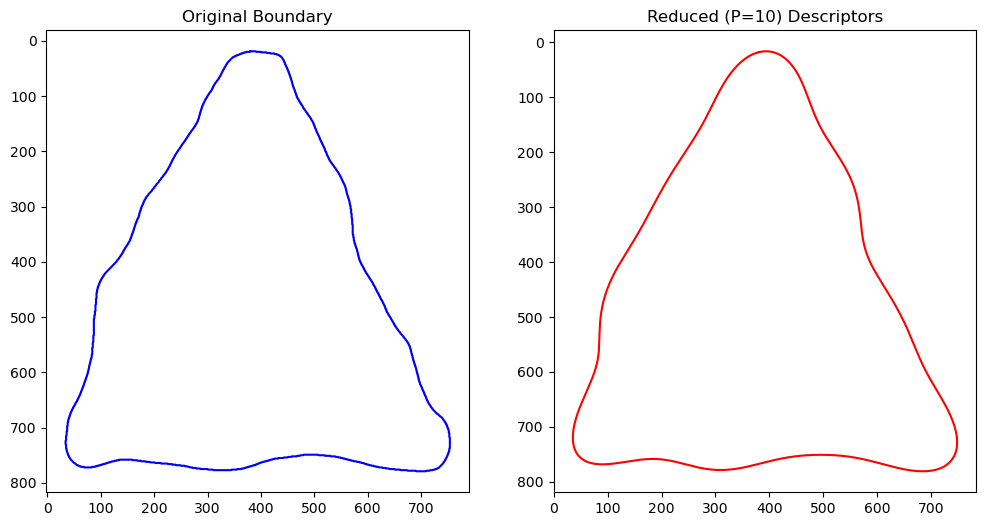

In [5]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1111(a)(triangle).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
boundary = contours[0].reshape(-1, 2)

# Represent boundary as complex numbers s = x + jy
s = boundary[:, 0] + 1j * boundary[:, 1]

# Compute Fourier Descriptors (DFT)
descriptors = np.fft.fft(s)

# Reduction: Keep only the first P coefficients to smooth/simplify shape
P = 10 # Number of descriptors to keep
reduced_descriptors = descriptors.copy()
reduced_descriptors[P:-P] = 0 # Zero out high frequency components

# Reconstruct using Inverse DFT
reconstructed_s = np.fft.ifft(reduced_descriptors)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.plot(boundary[:, 0], boundary[:, 1], 'b'); plt.title('Original Boundary'); plt.gca().invert_yaxis()
plt.subplot(1, 2, 2); plt.plot(reconstructed_s.real, reconstructed_s.imag, 'r'); plt.title(f'Reduced (P={P}) Descriptors'); plt.gca().invert_yaxis()
plt.show()